In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('asts.csv', sep=',', on_bad_lines='skip', parse_dates=['Create date'])

In [3]:
#df.head(3)

In [4]:
#df.tail(3)

In [5]:
#df.sample(3)

In [6]:
#df['Vendor'].astype(str).isnull().sum()

In [7]:
#df['Vendor'].astype(str).isnull().mean()

In [8]:
df.astype(str).isnull().mean()

#BioSample                                     0.000000
Organism group                                 0.000000
Scientific name                                0.000000
Isolation type                                 0.003530
Location                                       0.042990
Isolation source                               0.064154
Isolate                                        0.000000
Antibiotic                                     0.000000
Resistance phenotype                           0.000000
Measurement sign                               0.010947
MIC (mg/L)                                     0.023228
Disk diffusion (mm)                            0.987718
Laboratory typing platform                     0.308210
Vendor                                         0.364370
Laboratory typing method version or reagent    0.468013
Testing standard                               0.024803
Create date                                    0.000000
dtype: float64

In [11]:
# First step

In [9]:
df['Resistance phenotype'] = df['Resistance phenotype'].str.upper()
df['Scientific name'] = df['Scientific name'].str.strip()
df['Antibiotic'] = df['Antibiotic'].str.strip()

print(f"Успешно загружено строк: {len(df)}")
print("-" * 50)

Успешно загружено строк: 492115
--------------------------------------------------


## 1. ЭПИДЕМИОЛОГИЧЕСКИЕ ИНСАЙТЫ (Где и что циркулирует?)

In [10]:
top_pathogens = df['Scientific name'].value_counts().head(5)
print("\nТоп-5 самых частых возбудителей в выборке:")
print(top_pathogens)


Топ-5 самых частых возбудителей в выборке:
Scientific name
Escherichia coli                   165735
Staphylococcus pseudintermedius     35541
Klebsiella pneumoniae               29584
Campylobacter jejuni                22711
Acinetobacter baumannii             21703
Name: count, dtype: int64


In [11]:
# Распределение патогенов по локациям (отделениям)
# Показывает, какие бактерии преобладают в конкретных местах
pathogen_by_loc = df.groupby(['Location', 'Scientific name']).size().unstack(fill_value=0)
# Возьмем топ-5 локаций для наглядности
top_locations = df['Location'].value_counts().head(5).index
print("\nРаспределение бактерий по топ-5 локациям (кол-во тестов):")
print(pathogen_by_loc.loc[top_locations])


Распределение бактерий по топ-5 локациям (кол-во тестов):
Scientific name            Acinetobacter baumannii  Klebsiella pneumoniae  \
Location                                                                    
USA: District of Columbia                        0                    689   
USA                                            808                   3804   
USA:Boston                                     132                   3197   
USA:GA                                           0                    228   
USA:Washington, DC                           14377                      0   

Scientific name            Pseudomonas aeruginosa  Escherichia coli  \
Location                                                              
USA: District of Columbia                       0             37368   
USA                                          1305              3080   
USA:Boston                                    261              9046   
USA:GA                                        

## 2. КЛИНИЧЕСКИЕ ИНСАЙТЫ (К чему устойчивы патогены?)

In [12]:
# Расчет общего процента резистентности (R) для каждого антибиотика
# Предполагаем, что в 'Resistance phenotype' содержатся значения 'R' (Resistant), 'S', 'I'
antibiotic_r_rate = df.groupby('Antibiotic')['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
).sort_values(ascending=False)

print("\nТоп-10 антибиотиков с НАИВЫСШИМ уровнем резистентности (процент %R):")
print(antibiotic_r_rate.head(10).round(2))

# Поиск множественной устойчивости (MDR)
# Считаем, к какому количеству уникальных антибиотиков устойчив каждый образец (#BioSample)
mdr_analysis = df[df['Resistance phenotype'] == 'RESISTANT'].groupby('#BioSample')['Antibiotic'].nunique()
print("\nСтатистика множественной устойчивости (к какому числу препаратов устойчив один образец):")
print(mdr_analysis.describe())


Топ-10 антибиотиков с НАИВЫСШИМ уровнем резистентности (процент %R):
Antibiotic
sulfonamide      100.00
sulbactam        100.00
dicloxacillin    100.00
cefmetazole      100.00
cefamandole      100.00
cefaclor         100.00
pefloxacin       100.00
fluconazole       92.31
tedizolid         84.00
anidulafungin     82.61
Name: Resistance phenotype, dtype: float64

Статистика множественной устойчивости (к какому числу препаратов устойчив один образец):
count    20407.000000
mean         4.542265
std          4.278156
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         33.000000
Name: Antibiotic, dtype: float64


In [13]:
print(df['Resistance phenotype'])

0         SUSCEPTIBLE
1         SUSCEPTIBLE
2         SUSCEPTIBLE
3         SUSCEPTIBLE
4         SUSCEPTIBLE
             ...     
492110      RESISTANT
492111      RESISTANT
492112      RESISTANT
492113      RESISTANT
492114      RESISTANT
Name: Resistance phenotype, Length: 492115, dtype: str


## 3. ТРЕНДЫ И ДИНАМИКА (Куда движется ситуация?)

In [14]:
# Добавляем колонку Год-Месяц для анализа временных рядов
df['Year_Month'] = df['Create date'].dt.to_period('M')

# Динамика резистентности во времени (общий процент R по месяцам)
timeline_r = df.groupby('Year_Month')['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
)

print("\nИзменение общего уровня резистентности по месяцам (% RESISTANT):")
print(timeline_r.tail(12).round(2)) # Выводим последние 12 месяцев

# Визуализация тренда (по желанию можно раскомментировать)
# timeline_r.plot(kind='line', marker='o')
# plt.title('Динамика резистентности во времени')
# plt.ylabel('% Resistant (R)')
# plt.show()


Изменение общего уровня резистентности по месяцам (% RESISTANT):
Year_Month
2025-06    44.04
2025-07    54.43
2025-08    25.12
2025-09     0.03
2025-10    28.95
2025-11    23.49
2025-12    18.18
2026-01    28.09
2026-02    34.65
2026-03    48.83
2026-04    78.26
2026-05     0.00
Freq: M, Name: Resistance phenotype, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\3176104323.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Year_Month'] = df['Create date'].dt.to_period('M')


## 4. МЕТОДОЛОГИЧЕСКИЙ АУДИТ (Качество данных и платформ)

In [15]:
# Проверяем, как разные платформы/вендоры определяют резистентность
# Если у одного вендора процент R аномально выше, это повод для внутренней проверки
vendor_bias = df.groupby('Vendor')['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
)
print("\nПроцент выявления резистентности в зависимости от производителя (Vendor):")
print(vendor_bias.round(2))

# Анализ пропусков в критических цифровых данных
missing_mic = df['MIC (mg/L)'].isna().sum()
missing_disk = df['Disk diffusion (mm)'].isna().sum()
total_rows = len(df)

print(f"\nПропуски в МИК (MIC): {missing_mic} строк ({round(missing_mic/total_rows*100, 2)}%)")
print(f"Пропуски в Disk diffusion: {missing_disk} строк ({round(missing_disk/total_rows*100, 2)}%)")


Процент выявления резистентности в зависимости от производителя (Vendor):
Vendor
Beckman Coulter Inc         90.91
Becton Dickinson            19.25
Biomérieux                  35.16
Interscience                48.08
Liofilchem                  37.50
Liofilchem Inc.             83.33
Not applicable               0.00
SIRSCAN                      0.00
Siemens                     67.00
TREK Diagnostic Systems     53.43
Thermo Fisher Scientific    52.10
Thermo Scientific           78.95
Trek                         9.02
in-house                    37.25
Name: Resistance phenotype, dtype: float64

Пропуски в МИК (MIC): 11431 строк (2.32%)
Пропуски в Disk diffusion: 486071 строк (98.77%)


## БОНУС: Матрица "Бактерия х Антибиотик" для поиска слепых зон


Матрица резистентности (% R) для ключевых пар Бактерия-Антибиотик:
Antibiotic             fluconazole  sulbactam
Scientific name                              
Escherichia coli             100.0      100.0
Klebsiella pneumoniae          0.0      100.0

[Успешно] Тепловая карта сохранена в файл 'resistance_heatmap.png'


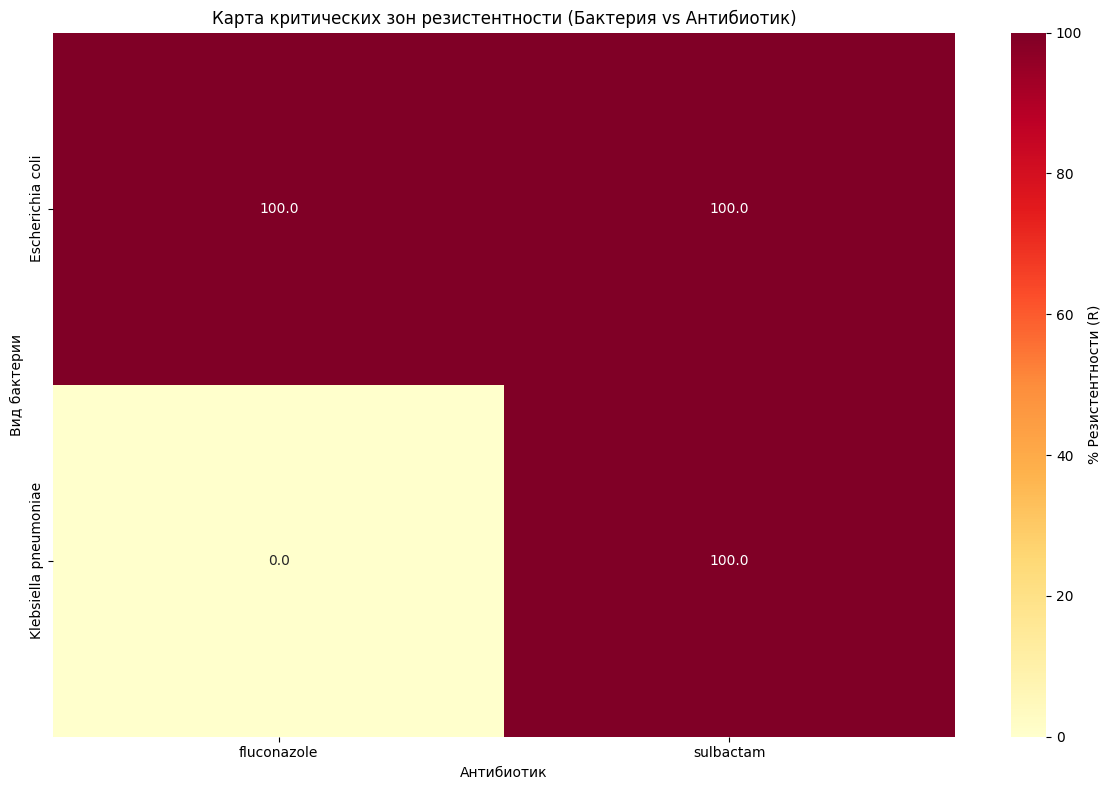

In [16]:
# Отфильтруем топ-5 бактерий и топ-10 антибиотиков для красивой тепловой карты
top_bact_names = top_pathogens.index
top_anti_names = antibiotic_r_rate.head(10).index

pivot_df = df[df['Scientific name'].isin(top_bact_names) & df['Antibiotic'].isin(top_anti_names)]
heatmap_data = pivot_df.groupby(['Scientific name', 'Antibiotic'])['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
).unstack(fill_value=0)

print("\nМатрица резистентности (% R) для ключевых пар Бактерия-Антибиотик:")
print(heatmap_data.round(1))

# Построение тепловой карты (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f", cbar_kws={'label': '% Резистентности (R)'})
plt.title('Карта критических зон резистентности (Бактерия vs Антибиотик)')
plt.ylabel('Вид бактерии')
plt.xlabel('Антибиотик')
plt.tight_layout()
plt.savefig('resistance_heatmap.png') # Сохранит график в папку с кодом
print("\n[Успешно] Тепловая карта сохранена в файл 'resistance_heatmap.png'")

In [17]:
# 1. Считаем, к какому количеству антибиотиков устойчив каждый уникальный образец
resistance_per_sample = df[df['Resistance phenotype'] == 'RESISTANT'].groupby(['#BioSample', 'Scientific name'])['Antibiotic'].nunique().reset_index()
resistance_per_sample.rename(columns={'Antibiotic': 'R_antibiotics_count'}, inplace=True)

# 2. Задаем критерий "самой резистентной" бактерии (например, устойчивость к 5 и более антибиотикам)
CRITERIA = 5 
superbugs = resistance_per_sample[resistance_per_sample['R_antibiotics_count'] >= CRITERIA]

# 3. Выводим результаты
total_superbugs_count = len(superbugs)
total_samples_in_db = df['#BioSample'].nunique()

print(f"--- АНАЛИЗ СУПЕРБАКТЕРИЙ (устойчивость к >= {CRITERIA} препаратам) ---")
print(f"Всего обнаружено самых резистентных образцов: {total_superbugs_count}")
print(f"Это составляет {round(total_superbugs_count / total_samples_in_db * 100, 2)}% от общего числа пациентов/образцов.\n")

# 4. Смотрим, какие именно виды бактерий чаще всего становятся такими супербактериями
print("Каких видов среди этих супербактерий больше всего (Топ-10):")
print(superbugs['Scientific name'].value_counts().head(10))

--- АНАЛИЗ СУПЕРБАКТЕРИЙ (устойчивость к >= 5 препаратам) ---
Всего обнаружено самых резистентных образцов: 7180
Это составляет 20.04% от общего числа пациентов/образцов.

Каких видов среди этих супербактерий больше всего (Топ-10):
Scientific name
Escherichia coli                                                   2405
Acinetobacter baumannii                                             897
Klebsiella pneumoniae                                               819
Salmonella enterica subsp. enterica serovar Infantis                441
Pseudomonas aeruginosa                                              367
Salmonella enterica subsp. enterica serovar Typhimurium var. 5-     273
Salmonella enterica                                                 170
Salmonella enterica subsp. enterica serovar Heidelberg              141
Salmonella enterica subsp. enterica serovar Typhimurium             133
Salmonella enterica subsp. enterica serovar Kentucky                125
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\568935508.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ab_df['Period'] = ab_df['Create date'].dt.to_period('Q')


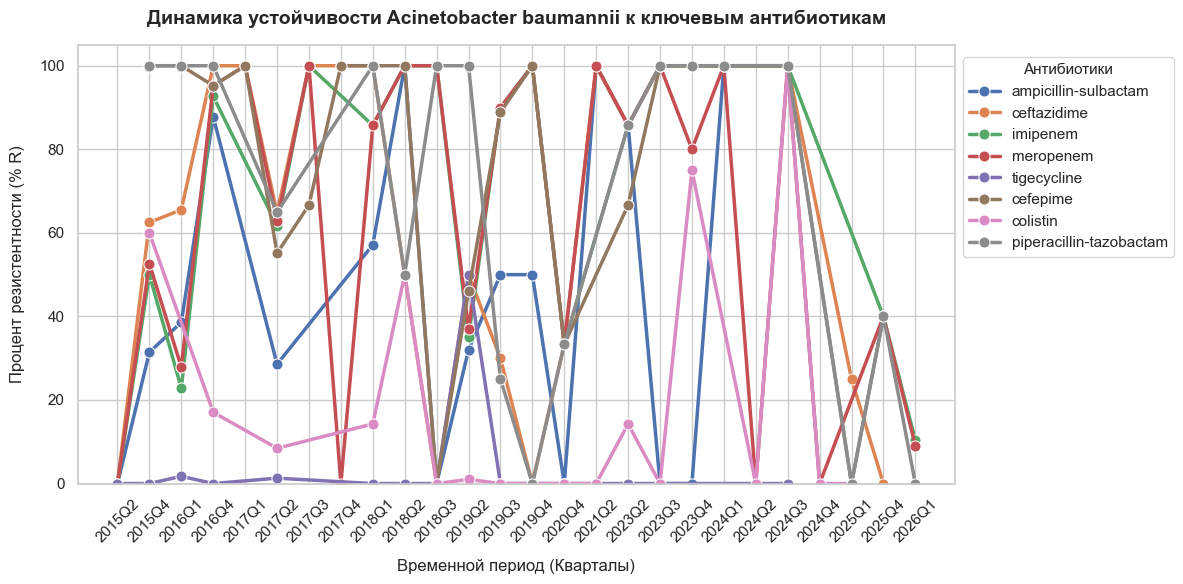

[Успешно] График динамики построен и сохранен как 'acinetobacter_resistance_trend.png'


In [18]:
# 2. ФИЛЬТРАЦИЯ ПО КОНКРЕТНОЙ БАКТЕРИИ
# Фильтруем датафрейм только по Acinetobacter baumannii
ab_df = df[df['Scientific name'] == 'Acinetobacter baumannii'].copy()

# Создаем временной интервал (группировка по кварталам 'Q' или месяцам 'M')
# Для больших данных КВАРТАЛЫ ('Q') обычно дают более плавный и понятный тренд
ab_df['Period'] = ab_df['Create date'].dt.to_period('Q')

# 3. ВЫБОР КЛЮЧЕВЫХ АНТИБИОТИКОВ
# Выберем топ-4 самых частых антибиотиков, на которые тестировали эту бактерию,
# либо вы можете жестко прописать нужные, например: ['Meropenem', 'Imipenem', 'Amikacin', 'Ciprofloxacin']
top_antibiotics = ab_df['Antibiotic'].value_counts().head(5).index

# Фильтруем данные только по этим антибиотикам
ab_filtered = ab_df[ab_df['Antibiotic'].isin(['meropenem', 'imipenem', 'colistin', 'piperacillin-tazobactam', 'cefepime', 'ceftazidime', 'tigecycline', 'ampicillin-sulbactam'])]

# 4. РАСЧЕТ ПРОЦЕНТА РЕЗИСТЕНТНОСТИ (% R)
# Группируем по периоду и антибиотику, считая долю исходов 'R'
trend_data = ab_filtered.groupby(['Period', 'Antibiotic'])['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
).reset_index(name='Resistance_Rate')

# Переводим периоды в строковый формат, чтобы matplotlib корректно отобразил ось X
trend_data['Period'] = trend_data['Period'].astype(str)
# 5. ПОСТРОЕНИЕ ГРАФИКА
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid") # Красивая светлая сетка

# Строим линии для каждого антибиотика
sns.lineplot(
    data=trend_data, 
    x='Period', 
    y='Resistance_Rate', 
    hue='Antibiotic', 
    marker='o', 
    linewidth=2.5,
    markersize=8
)

# Настройка внешнего вида
plt.title('Динамика устойчивости Acinetobacter baumannii к ключевым антибиотикам', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Временной период (Кварталы)', fontsize=12, labelpad=10)
plt.ylabel('Процент резистентности (% R)', fontsize=12, labelpad=10)
plt.ylim(0, 105) # Проценты от 0 до 100
plt.xticks(rotation=45) # Поворачиваем подписи дат, чтобы они не слипались

# Настройка легенды
plt.legend(title='Антибиотики', title_fontsize='11', loc='lower left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# Сохранение и показ графика
plt.savefig('acinetobacter_resistance_trend.png', dpi=300)
plt.show()

print("[Успешно] График динамики построен и сохранен как 'acinetobacter_resistance_trend.png'")


In [19]:
print(df['Antibiotic'].isin(['piperacillin-tazobactam']).any())

True


In [20]:
list(df['Antibiotic'].unique())

['amikacin',
 'ceftriaxone',
 'cefazolin',
 'piperacillin-tazobactam',
 'ampicillin',
 'amoxicillin-clavulanic acid',
 'cefepime',
 'ciprofloxacin',
 'gentamicin',
 'meropenem',
 'ertapenem',
 'chloramphenicol',
 'azithromycin',
 'erythromycin',
 'cefoxitin',
 'ceftazidime',
 'cefotaxime',
 'clindamycin',
 'amoxicillin',
 'imipenem',
 'colistin',
 'ethambutol',
 'benzylpenicillin',
 'enrofloxacin',
 'fluoroquinolone',
 'aztreonam',
 'daptomycin',
 'doripenem',
 'cefovecin',
 'bacitracin',
 'amphotericin B',
 'cefixime',
 'Imipenem-EDTA-PA',
 'ampicillin-sulbactam',
 'capreomycin',
 'ceftaroline',
 'trimethoprim-sulfamethoxazole',
 'levofloxacin',
 'tobramycin',
 'tetracycline',
 'penicillin',
 'ceftiofur',
 'nalidixic acid',
 'cefotaxime-clavulanic acid',
 'isoniazid',
 'cefpodoxime',
 'anidulafungin',
 'ceftazidime-avibactam',
 'avilamycin',
 'cefiderocol',
 'fusidic acid',
 'oxacillin',
 'ceftolozane-tazobactam',
 'cefuroxime',
 'piperacillin',
 'dicloxacillin',
 'chlortetracycline',

In [21]:
#!pip install plotly

C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\2950099579.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ab_df['Period'] = ab_df['Create date'].dt.to_period('Q')


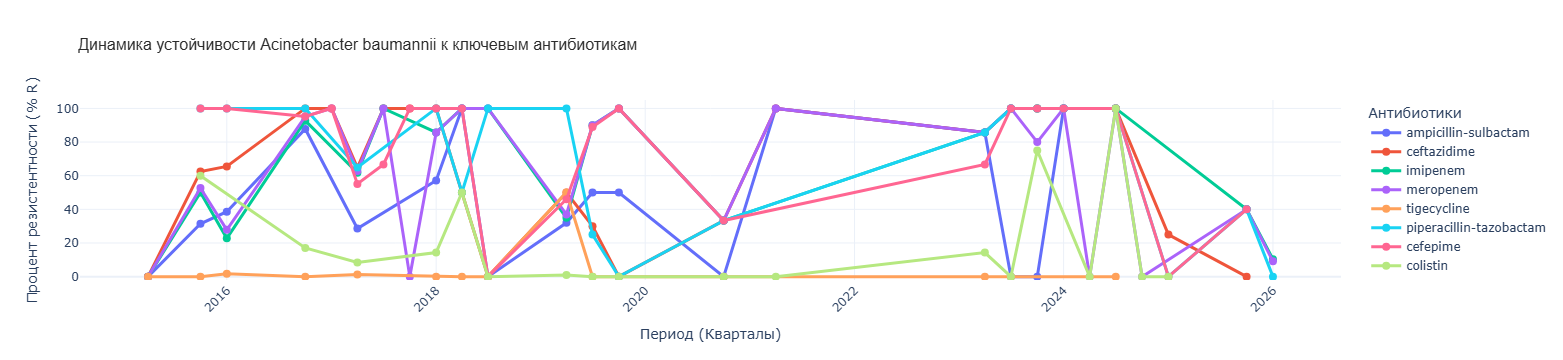

[Успешно] Интерактивный график сохранен как 'acinetobacter_resistance_plotly.html'


In [32]:
import plotly.express as px

# --- 2. ФИЛЬТРАЦИЯ ПО КОНКРЕТНОЙ БАКТЕРИИ ---
# Фильтруем датафрейм только по Acinetobacter baumannii
ab_df = df[df['Scientific name'] == 'Acinetobacter baumannii'].copy()

# Создаем временной интервал (группировка по кварталам 'Q')
ab_df['Period'] = ab_df['Create date'].dt.to_period('Q')

# --- 3. ВЫБОР ВАШЕГО СПИСКА АНТИБИОТИКОВ ---
my_antibiotics = [
    'meropenem', 'imipenem', 'colistin', 'piperacillin-tazobactam', 
    'cefepime', 'ceftazidime', 'tigecycline', 'ampicillin-sulbactam'
]

# Фильтруем данные строго по вашему списку
ab_filtered = ab_df[ab_df['Antibiotic'].isin(my_antibiotics)]

# --- 4. РАСЧЕТ ПРОЦЕНТА РЕЗИСТЕНТНОСТИ (% R) ---
trend_data = ab_filtered.groupby(['Period', 'Antibiotic'])['Resistance phenotype'].apply(
    lambda x: (x == 'RESISTANT').sum() / x.count() * 100
).reset_index(name='Resistance_Rate')

# Переводим периоды в строковый формат для корректного отображения в Plotly
trend_data['Period'] = trend_data['Period'].dt.to_timestamp()

# Сортируем данные по периодам, чтобы линии на графике шли последовательно
trend_data = trend_data.sort_values('Period')


# --- 5. ПОСТРОЕНИЕ ИНТЕРАКТИВНОГО ГРАФИКА (PLOTLY) ---
fig = px.line(
    trend_data, 
    x='Period', 
    y='Resistance_Rate', 
    color='Antibiotic',       # Разделение линий по вашим антибиотикам
    title='Динамика устойчивости Acinetobacter baumannii к ключевым антибиотикам',
    markers=True,             # Включаем точки (маркеры) на изгибах линий
    labels={                  # Красивые названия осей во всплывающих подсказках
        'Period': 'Период (Кварталы)',
        'Resistance_Rate': 'Процент резистентности (% R)',
        'Antibiotic': 'Антибиотик'
    }
)

# Настройка стиля и удобства отображения
fig.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    title_font_color="#2b2b2b",
    xaxis_tickangle=-45,       # Поворачиваем даты, чтобы не перекрывали друг друга
    yaxis_range=[-2, 105],     # Ограничиваем ось Y от 0 до 100 (с небольшим запасом для красоты)
    template='plotly_white',   # Чистый белый фон с аккуратной сеткой
    hovermode='x unified',     # При наведении показывает данные всех 8 антибиотиков сразу
    legend=dict(
        title_text='Антибиотики',
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02                 # Убираем легенду вправо, чтобы она не мешала графику
    )
)

# Настройка самих линий (толщина и размер точек)
fig.update_traces(
    line_width=3, 
    marker_size=8,
    hovertemplate="%{y:.1f}%"   # Округляем процент в подсказке до 1 знака после запятой
)

# Показ графика (откроется прямо в Jupyter Notebook, Colab или браузере)
fig.show()

# Сохранение в интерактивный HTML файл
fig.write_html('acinetobacter_resistance_plotly.html')
print("[Успешно] Интерактивный график сохранен как 'acinetobacter_resistance_plotly.html'")

In [23]:
import matplotlib.pyplot as plt

In [24]:
import seaborn as sns

## 4. Тренд резистентности во времени

In [25]:
# Превращаем колонку с датой в формат datetime
df['Create date'] = pd.to_datetime(df['Create date'])
df['Year'] = df['Create date'].dt.year

# Считаем долю Resistant от общего числа тестов по годам
yearly_trend = df.groupby('Year')['Resistance phenotype'].value_counts(normalize=True).unstack() * 100

print("Изменение доли устойчивых штаммов по годам (%):")
print(yearly_trend['RESISTANT'])

Изменение доли устойчивых штаммов по годам (%):
Year
2013    51.778094
2014    24.954727
2015    17.782093
2016    30.194156
2017    20.420901
2018    13.620654
2019    12.464069
2020    17.690600
2021    11.493616
2022    12.659912
2023    18.657913
2024    33.847830
2025    19.988778
2026    29.290113
Name: RESISTANT, dtype: float64


In [26]:
# 1. Настройка стиля графиков для красивого отображения
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.titlesize": 14})

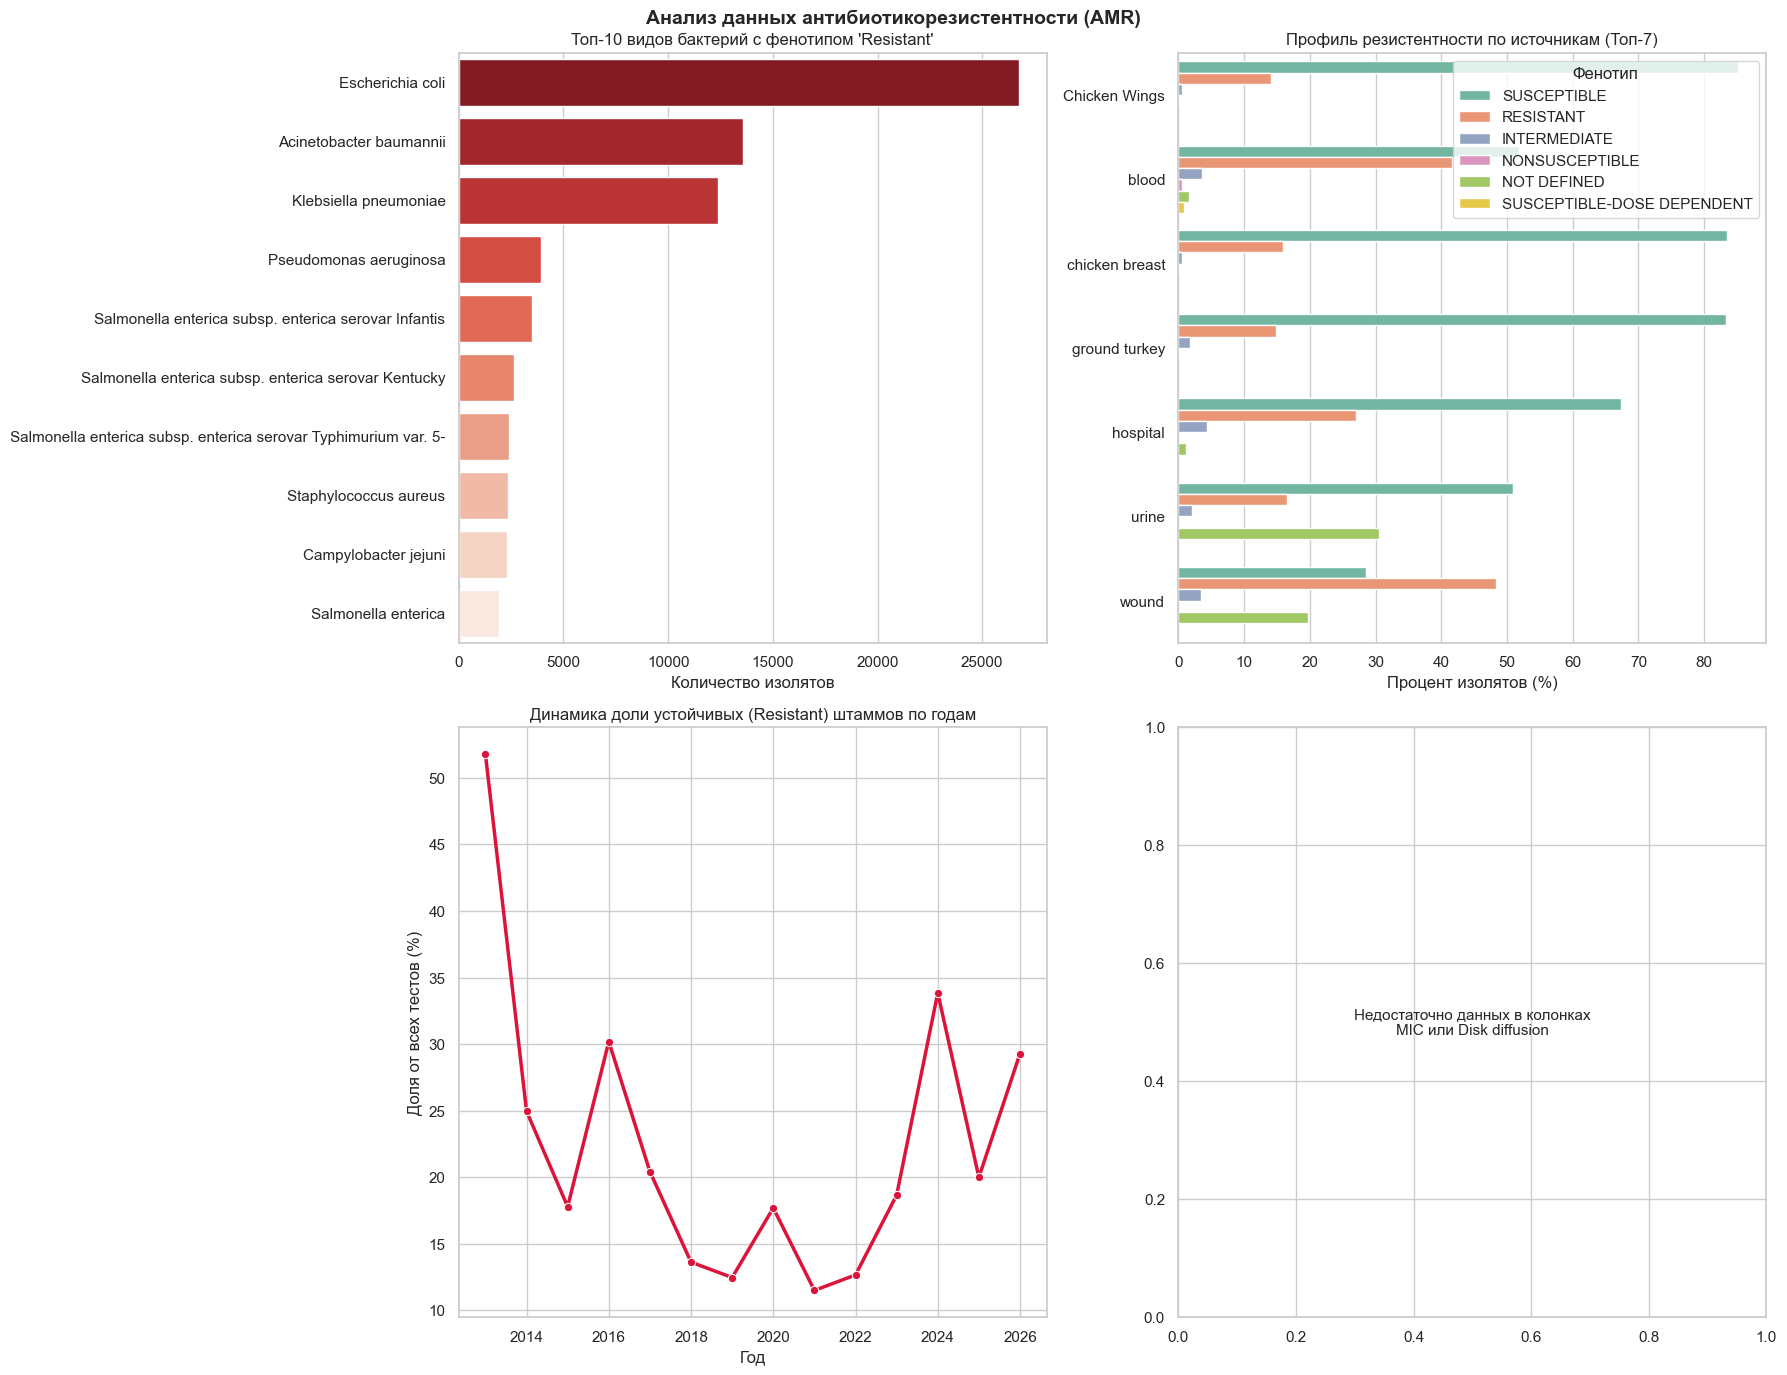

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Анализ данных антибиотикорезистентности (AMR)", fontweight="bold")
ax3 = axes[1, 0]
trend_data = (
    df.groupby("Year")["Resistance phenotype"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

if "RESISTANT" in trend_data.columns:
    sns.lineplot(
        x=trend_data.index,
        y=trend_data["RESISTANT"],
        ax=ax3,
        marker="o",
        color="crimson",
        linewidth=2.5,
    )
    ax3.set_title("Динамика доли устойчивых (Resistant) штаммов по годам")
    ax3.set_ylabel("Доля от всех тестов (%)")
    ax3.set_xlabel("Год")
    ax3.xaxis.set_major_locator(
        plt.MaxNLocator(integer=True)
    )  # Только целые года
else:
    ax3.text(
        0.5,
        0.5,
        "Нет данных по годам\nили отсутствует фенотип Resistant",
        ha="center",
        va="center",
    )
ax1 = axes[0, 0]
resistant_df = df[df["Resistance phenotype"] == "RESISTANT"]
top_bacteria = resistant_df["Scientific name"].value_counts().head(10)

sns.barplot(
    x=top_bacteria.values,
    y=top_bacteria.index,
    ax=ax1,
    palette="Reds_r",
    hue=top_bacteria.index,
    legend=False,
)
ax1.set_title("Топ-10 видов бактерий с фенотипом 'Resistant'")
ax1.set_xlabel("Количество изолятов")
ax1.set_ylabel("")

# ----------------------------------------------------------------------
# ГРАФИК 2: Распределение штаммов по источникам изоляции
# ----------------------------------------------------------------------
ax2 = axes[0, 1]
# Считаем процентное соотношение внутри каждого источника
source_data = (
    df.groupby("Isolation source")["Resistance phenotype"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

# Ограничимся топ-7 источниками, чтобы график не перегружать
top_sources = df["Isolation source"].value_counts().head(7).index
source_data_filtered = source_data[
    source_data["Isolation source"].isin(top_sources)
]

sns.barplot(
    x="Percentage",
    y="Isolation source",
    hue="Resistance phenotype",
    data=source_data_filtered,
    ax=ax2,
    palette="Set2",
)
ax2.set_title("Профиль резистентности по источникам (Топ-7)")
ax2.set_xlabel("Процент изолятов (%)")
ax2.set_ylabel("")
ax2.legend(title="Фенотип")

# ГРАФИК 4: Корреляция между методами (MIC vs Disk diffusion)
# ----------------------------------------------------------------------
ax4 = axes[1, 1]
# Очищаем данные от пустых значений для корректного boxplot
clean_measurements = df.dropna(
    subset=["MIC (mg/L)", "Disk diffusion (mm)", "Resistance phenotype"]
)

if not clean_measurements.empty:
    # Используем boxplot, чтобы увидеть распределение зоны задержки (Disk diffusion)
    # для разных фенотипов. Обычно у Resistant зона маленькая, у Susceptible — большая.
    sns.boxplot(
        x="Resistance phenotype",
        y="Disk diffusion (mm)",
        data=clean_measurements,
        ax=ax4,
        palette="Pastel1",
        hue="Resistance phenotype",
        legend=False,
    )
    ax4.set_title("Диаметр зоны диско-диффузии для разных фенотипов")
    ax4.set_xlabel("Фенотип резистентности")
    ax4.set_ylabel("Диаметр зоны (мм)")
else:
    ax4.text(
        0.5,
        0.5,
        "Недостаточно данных в колонках\nMIC или Disk diffusion",
        ha="center",
        va="center",
    )

# Корректируем расположение элементов, чтобы подписи не накладывались
plt.tight_layout()

plt.savefig('amr_insights_dashboard.png', dpi=300, bbox_inches='tight')

# Отображаем графики на экране
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\1512384557.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  kp_df["Period"] = kp_df["Create date"].dt.to_period("Q")


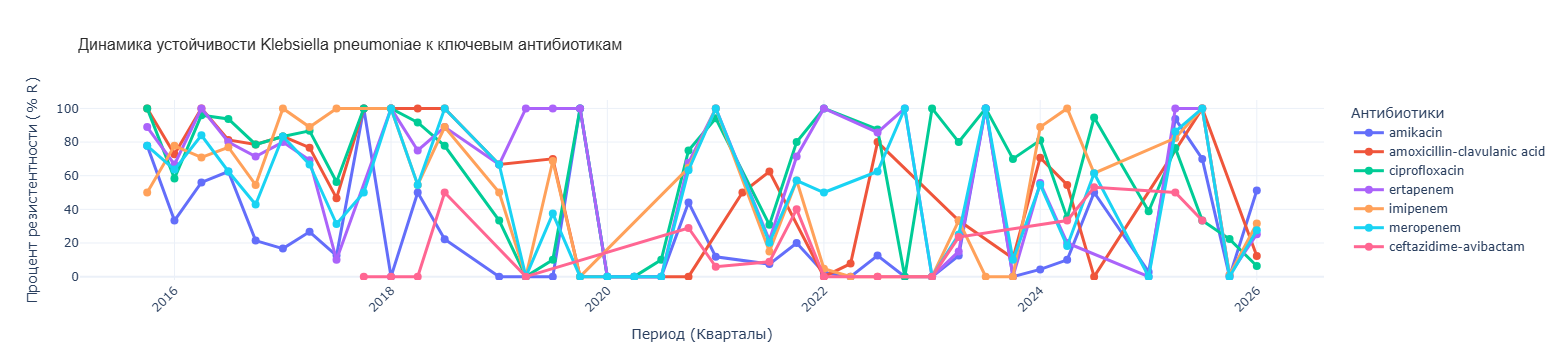

[Успешно] Интерактивный график сохранен как 'klebsiella_resistance_plotly.html'


In [33]:
# 2. ФИЛЬТРАЦИЯ ПО КОНКРЕТНОЙ БАКТЕРИИ 
# Фильтруем датафрейм только по Klebsiella pneumoniae
kp_df = df[df["Scientific name"] == "Klebsiella pneumoniae"].copy()

# Создаем временной интервал (группировка по кварталам 'Q')
kp_df["Period"] = kp_df["Create date"].dt.to_period("Q")

# --- 3. ВЫБОР СПИСКА АНТИБИОТИКОВ ДЛЯ K. PNEUMONIAE ---
# Обновленный список: добавлены ключевые цефалоспорины, карбапенемы и защищенные бета-лактамы
my_antibiotics = [
    "meropenem",
    "imipenem",
    "ceftazidime-avibactam",  # Крайне важен для карбапенем-резистентной Клебсиеллы
    "ertapenem",
    "amoxicillin-clavulanic acid",  # Базовая защита
    "ciprofloxacin",  # Фторхинолон для полноты картины
    "amikacin",  # Аминогликозид резерва
]

# Фильтруем данные строго по вашему списку
kp_filtered = kp_df[kp_df["Antibiotic"].isin(my_antibiotics)]

# --- 4. РАСЧЕТ ПРОЦЕНТА РЕЗИСТЕНТНОСТИ (% R) ---
trend_data = (
    kp_filtered.groupby(["Period", "Antibiotic"])["Resistance phenotype"]
    .apply(lambda x: (x.str.upper() == "RESISTANT").sum() / x.count() * 100)
    .reset_index(name="Resistance_Rate")
)

# Переводим периоды в строковый формат для корректного отображения в Plotly
trend_data['Period'] = trend_data['Period'].dt.to_timestamp()

# Сортируем данные по периодам, чтобы линии на графике шли последовательно
trend_data = trend_data.sort_values("Period")


# --- 5. ПОСТРОЕНИЕ ИНТЕРАКТИВНОГО ГРАФИКА (PLOTLY) ---
fig = px.line(
    trend_data,
    x="Period",
    y="Resistance_Rate",
    color="Antibiotic",  # Разделение линий по антибиотикам
    title="Динамика устойчивости Klebsiella pneumoniae к ключевым антибиотикам",
    markers=True,  # Включаем точки (маркеры) на изгибах линий
    labels={  # Красивые названия осей во всплывающих подсказках
        "Period": "Период (Кварталы)",
        "Resistance_Rate": "Процент резистентности (% R)",
        "Antibiotic": "Антибиотик",
    },
)

# Настройка стиля и удобства отображения
fig.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    title_font_color="#2b2b2b",
    xaxis_tickangle=-45,  # Поворачиваем даты, чтобы не перекрывали друг друга
    yaxis_range=[
        -2,
        105,
    ],  # Ограничиваем ось Y от 0 до 100 (с небольшим запасом для красоты)
    template="plotly_white",  # Чистый белый фон с аккуратной сеткой
    hovermode="x unified",  # При наведении показывает данные всех антибиотиков сразу
    legend=dict(
        title_text="Антибиотики",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,  # Убираем легенду вправо, чтобы она не мешала графику
    ),
)

# Настройка самих линий (толщина и размер точек)
fig.update_traces(
    line_width=3,
    marker_size=8,
    hovertemplate="%{y:.1f}%",  # Округляем процент в подсказке до 1 знака после запятой
)

# Показ графика
fig.show()

# Сохранение в интерактивный HTML файл
fig.write_html("klebsiella_resistance_plotly.html")
print("[Успешно] Интерактивный график сохранен как 'klebsiella_resistance_plotly.html'")

In [32]:
#!pip install -U scikit-learn

In [33]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# --- 1. ПОДГОТОВКА ДАННЫХ ---
# Выбираем целевую переменную (Y) и признаки для обучения (X)
# Исключаем прямые ответы (MIC, Disk diffusion), если хотим предсказывать фенотип
# ТОЛЬКО на основе биологических и географических данных.
feature_cols = [
    "Organism group",
    "Scientific name",
    "Isolation type",
    "Location",
    "Isolation source",
    "Antibiotic",
]
target_col = "Resistance phenotype"

# Очищаем датасет от пропусков в целевой переменной и признаках
ml_df = df.dropna(subset=[target_col] + feature_cols).copy()

# Стандартизируем целевую переменную к двум классам: 1 (Resistant) и 0 (Susceptible)
# Игнорируем промежуточные (Intermediate), чтобы модель училась точнее
ml_df = ml_df[ml_df[target_col].str.upper().isin(["RESISTANT", "SUSCEPTIBLE"])]
y = (ml_df[target_col].str.upper() == "RESISTANT").astype(int)

# Преобразуем категориальные текстовые признаки в числа (One-Hot Encoding)
X = pd.get_dummies(ml_df[feature_cols], drop_first=True)

# --- 2. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ ---
# 80% данных идет на обучение, 20% — на проверку качества
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. ОБУЧЕНИЕ МОДЕЛИ ---
# Используем Random Forest — он отлично справляется с табличными и категориальными данными
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# --- 4. ОЦЕНКА КАЧЕСТВА МОДЕЛИ ---
y_pred = model.predict(X_test)

print("--- ОТЧЕТ О КАЧЕСТВЕ КЛАССИФИКАЦИИ ---")
print(classification_report(y_test, y_pred, target_names=["Susceptible", "Resistant"]))

# --- 5. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ---
# Смотрим, какие факторы (вид, локация, антибиотик) сильнее всего влияют на резистентность
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- ТОП-5 САМЫХ ВАЖНЫХ ФАКТОРОВ ДЛЯ ПРЕДСКАЗАНИЯ ---")
# Агрегируем dummy-переменные обратно до исходных колонок для понятности
feature_importance_dict = {}
for col in feature_cols:
    # Суммируем важность всех dummy-колонок, относящихся к одному признаку
    sum_importance = sum(
        importances[i] for i, name in enumerate(X.columns) if name.startswith(col)
    )
    feature_importance_dict[col] = sum_importance

sorted_features = sorted(
    feature_importance_dict.items(), key=lambda x: x[1], reverse=True
)
for name, importance in sorted_features[:5]:
    print(f"{name}: {importance:.4f}")

--- ОТЧЕТ О КАЧЕСТВЕ КЛАССИФИКАЦИИ ---
              precision    recall  f1-score   support

 Susceptible       0.90      0.94      0.92     57880
   Resistant       0.75      0.63      0.68     16587

    accuracy                           0.87     74467
   macro avg       0.82      0.78      0.80     74467
weighted avg       0.87      0.87      0.87     74467


--- ТОП-5 САМЫХ ВАЖНЫХ ФАКТОРОВ ДЛЯ ПРЕДСКАЗАНИЯ ---
Antibiotic: 0.3719
Location: 0.2199
Isolation source: 0.2019
Scientific name: 0.1339
Organism group: 0.0549


C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\414774927.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ec_df["Period"] = ec_df["Create date"].dt.to_period("Q")


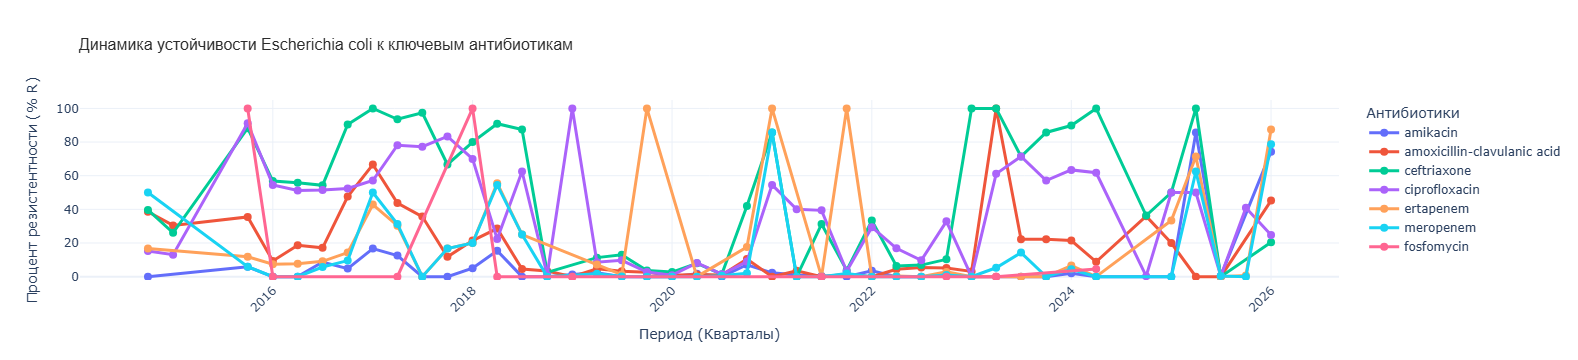

[Успешно] Интерактивный график сохранен как 'escherichia_coli_resistance_plotly.html'


In [35]:
# 2. ФИЛЬТРАЦИЯ ПО КОНКРЕТНОЙ БАКТЕРИИ
# Фильтруем датафрейм только по Escherichia coli
ec_df = df[df["Scientific name"] == "Escherichia coli"].copy()

# Создаем временной интервал (группировка по кварталам 'Q')
ec_df["Period"] = ec_df["Create date"].dt.to_period("Q")

# --- 3. ВЫБОР СПИСКА АНТИБИОТИКОВ ДЛЯ E. COLI ---
# Обновленный список: добавлены ключевые цефалоспорины, фторхинолоны и уроантисептики
my_antibiotics_ec = [
    "ceftriaxone",  # Цефалоспорин III поколения, критически важный для E. coli
    "ciprofloxacin",  # Фторхинолон, часто применяемый при ИМП
    "amoxicillin-clavulanic acid",  # Базовый защищенный пенициллин
    "meropenem",  # Карбапенем резерва
    "ertapenem",  # Карбапенем для полирезистентных штаммов
    "fosfomycin",  # Ключевой препарат для терапии неосложненных ИМП
    "amikacin",  # Аминогликозид резерва
]

# Фильтруем данные строго по списку для E. coli
ec_filtered = ec_df[ec_df["Antibiotic"].isin(my_antibiotics_ec)]

# --- 4. РАСЧЕТ ПРОЦЕНТА РЕЗИСТЕНТНОСТИ (% R) ---
trend_data_ec = (
    ec_filtered.groupby(["Period", "Antibiotic"])["Resistance phenotype"]
    .apply(lambda x: (x.str.upper() == "RESISTANT").sum() / x.count() * 100)
    .reset_index(name="Resistance_Rate")
)

# Переводим периоды в строковый формат для корректного отображения в Plotly
trend_data_ec['Period'] = trend_data_ec['Period'].dt.to_timestamp()

# Сортируем данные по периодам, чтобы линии на графике шли последовательно
trend_data_ec = trend_data_ec.sort_values("Period")


# --- 5. ПОСТРОЕНИЕ ИНТЕРАКТИВНОГО ГРАФИКА (PLOTLY) ---
fig_ec = px.line(
    trend_data_ec,
    x="Period",
    y="Resistance_Rate",
    color="Antibiotic",  # Разделение линий по антибиотикам
    title="Динамика устойчивости Escherichia coli к ключевым антибиотикам",
    markers=True,  # Включаем точки (маркеры) на изгибах линий
    labels={  # Красивые названия осей во всплывающих подсказках
        "Period": "Период (Кварталы)",
        "Resistance_Rate": "Процент резистентности (% R)",
        "Antibiotic": "Антибиотик",
    },
)

# Настройка стиля и удобства отображения
fig_ec.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    title_font_color="#2b2b2b",
    xaxis_tickangle=-45,  # Поворачиваем даты, чтобы не перекрывали друг друга
    yaxis_range=[
        -2,
        105,
    ],  # Ограничиваем ось Y от 0 до 100 (с небольшим запасом для красоты)
    template="plotly_white",  # Чистый белый фон с аккуратной сеткой
    hovermode="x unified",  # При наведении показывает данные всех антибиотиков сразу
    legend=dict(
        title_text="Антибиотики",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,  # Убираем легенду вправо, чтобы она не мешала графику
    ),
)

# Настройка самих линий (толщина и размер точек)
fig_ec.update_traces(
    line_width=3,
    marker_size=8,
    hovertemplate="%{y:.1f}%",  # Округляем процент в подсказке до 1 знака после запятой
)

# Показ графика
fig_ec.show()

# Сохранение в интерактивный HTML файл
fig_ec.write_html("escherichia_coli_resistance_plotly.html")
print(
    "[Успешно] Интерактивный график сохранен как 'escherichia_coli_resistance_plotly.html'"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\1999075154.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pa_df["Period"] = pa_df["Create date"].dt.to_period("Q")


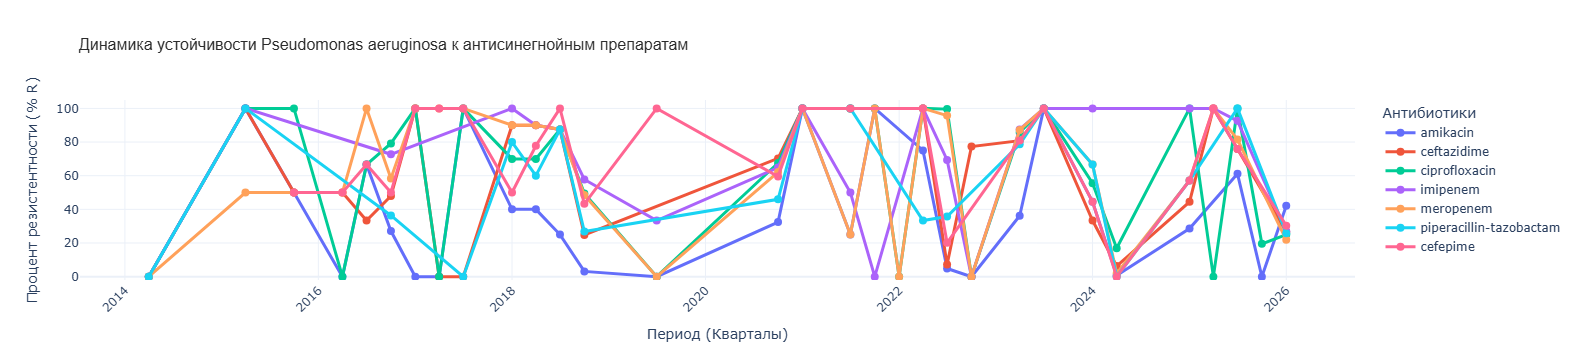

[Успешно] Интерактивный график сохранен как 'pseudomonas_aeruginosa_resistance_plotly.html'


In [36]:
# 2. ФИЛЬТРАЦИЯ ПО КОНКРЕТНОЙ БАКТЕРИИ
# Фильтруем датафрейм только по Pseudomonas aeruginosa
pa_df = df[df["Scientific name"] == "Pseudomonas aeruginosa"].copy()

# Создаем временной интервал (группировка по кварталам 'Q')
pa_df["Period"] = pa_df["Create date"].dt.to_period("Q")

# --- 3. ВЫБОР СПИСКА АНТИБИОТИКОВ ДЛЯ P. AERUGINOSA ---
# Обновленный список: строго антисинегнойные препараты (цефалоспорины, карбапенемы, фторхинолоны)
# Внимание: Ertapenem убран, так как он НЕ действует на Pseudomonas aeruginosa
my_antibiotics_pa = [
    "ceftazidime",  # Антисинегнойный цефалоспорин III поколения
    "cefepime",  # Антисинегнойный цефалоспорин IV поколения
    "piperacillin-tazobactam",  # Защищенный антисинегнойный пенициллин
    "meropenem",  # Карбапенем с высокой активностью против синегнойной палочки
    "imipenem",  # Карбапенем резерва
    "ciprofloxacin",  # Единственный доступный пероральный антисинегнойный препарат
    "amikacin",  # Аминогликозид, часто применяемый в комбинациях
]

# Фильтруем данные строго по списку для P. aeruginosa
pa_filtered = pa_df[pa_df["Antibiotic"].isin(my_antibiotics_pa)]

# --- 4. РАСЧЕТ ПРОЦЕНТА РЕЗИСТЕНТНОСТИ (% R) ---
trend_data_pa = (
    pa_filtered.groupby(["Period", "Antibiotic"])["Resistance phenotype"]
    .apply(lambda x: (x.str.upper() == "RESISTANT").sum() / x.count() * 100)
    .reset_index(name="Resistance_Rate")
)

# Переводим периоды в строковый формат для корректного отображения в Plotly
trend_data_pa['Period'] = trend_data_pa['Period'].dt.to_timestamp()

# Сортируем данные по периодам, чтобы линии на графике шли последовательно
trend_data_pa = trend_data_pa.sort_values("Period")


# --- 5. ПОСТРОЕНИЕ ИНТЕРАКТИВНОГО ГРАФИКА (PLOTLY) ---
fig_pa = px.line(
    trend_data_pa,
    x="Period",
    y="Resistance_Rate",
    color="Antibiotic",  # Разделение линий по антибиотикам
    title="Динамика устойчивости Pseudomonas aeruginosa к антисинегнойным препаратам",
    markers=True,  # Включаем точки (маркеры) на изгибах линий
    labels={  # Красивые названия осей во всплывающих подсказках
        "Period": "Период (Кварталы)",
        "Resistance_Rate": "Процент резистентности (% R)",
        "Antibiotic": "Антибиотик",
    },
)

# Настройка стиля и удобства отображения
fig_pa.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    title_font_color="#2b2b2b",
    xaxis_tickangle=-45,  # Поворачиваем даты, чтобы не перекрывали друг друга
    yaxis_range=[
        -2,
        105,
    ],  # Ограничиваем ось Y от 0 до 100 (с небольшим запасом для красоты)
    template="plotly_white",  # Чистый белый фон с аккуратной сеткой
    hovermode="x unified",  # При наведении показывает данные всех антибиотиков сразу
    legend=dict(
        title_text="Антибиотики",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,  # Убираем легенду вправо, чтобы она не мешала графику
    ),
)

# Настройка самих линий (толщина и размер точек)
fig_pa.update_traces(
    line_width=3,
    marker_size=8,
    hovertemplate="%{y:.1f}%",  # Округляем процент в подсказке до 1 знака после запятой
)

# Показ графика
fig_pa.show()

# Сохранение в интерактивный HTML файл
fig_pa.write_html("pseudomonas_aeruginosa_resistance_plotly.html")
print(
    "[Успешно] Интерактивный график сохранен как 'pseudomonas_aeruginosa_resistance_plotly.html'"
)

In [37]:
#!pip install prophet

In [38]:
from prophet import Prophet

In [37]:
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet

warnings.filterwarnings("ignore")

# --- 1. СТРУКТУРА ПАТОГЕНОВ И АНТИБИОТИКОВ ---
target_pathogens = {
    "Escherichia coli": [
        "ceftriaxone",
        "ciprofloxacin",
        "amoxicillin-clavulanic acid",
        "meropenem",
    ],
    "Klebsiella pneumoniae": [
        "meropenem",
        "ceftazidime-avibactam",
        "ciprofloxacin",
        "amikacin",
    ],
    "Acinetobacter baumannii": [
        "meropenem",
        "imipenem",
        "amikacin",
        "colistin", 
        "piperacillin-tazobactam",
        "ceftazidime", 
        "tigecycline", "ampicillin-sulbactam"
    ],
    "Pseudomonas aeruginosa": [
        "ceftazidime",
        "cefepime",
        "piperacillin-tazobactam",
        "meropenem",
    ],
}

# --- 2. ПОДГОТОВКА ИСХОДНЫХ ДАННЫХ ---
df_ml = df.copy()

# ДЛЯ PERIOD ИСПОЛЬЗУЕМ 'Q' (как требует Pandas для to_period)
df_ml["Quarter_Start"] = (
    df_ml["Create date"].dt.to_period("Q").dt.to_timestamp()
)
df_ml["Is_Resistant"] = (
    df_ml["Resistance phenotype"].str.upper() == "RESISTANT"
).astype(int)

# Сводный список для текстового отчета
report_summary = []

# --- 3. ЦИКЛ ВЫЧИСЛЕНИЙ И ВИЗУАЛИЗАЦИИ ---
for pathogen, antibiotics in target_pathogens.items():
    print(
        f"\n{'='*30}\nРАСЧЕТ И СТРОИТЕЛЬСТВО ГРАФИКА ДЛЯ: {pathogen}\n{'='*30}"
    )

    # Инициализируем интерактивный график Plotly для текущей бактерии
    fig = go.Figure()

    for ab in antibiotics:
        # Фильтрация данных по паре Патоген + Антибиотик
        sub_df = df_ml[
            (df_ml["Scientific name"] == pathogen)
            & (df_ml["Antibiotic"] == ab)
        ]

        # Проверка объема данных (нужно хотя бы 6-8 исторических кварталов для тренда)
        ts_data = (
            sub_df.groupby("Quarter_Start")["Is_Resistant"]
            .apply(lambda x: x.sum() / x.count())
            .reset_index()
        )

        if len(ts_data) < 6:
            print(
                f"[Пропущено] Недостаточно исторических точек для {pathogen} + {ab}"
            )
            continue

        # Форматирование под Prophet (шкалируем y в 0...1 для логистического тренда)
        ts_data.columns = ["ds", "y"]
        ts_data["cap"] = 1.0
        ts_data["floor"] = 0.0

        # Настройка и обучение модели
        model = Prophet(
            growth="logistic",
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05,  # Гибкость тренда
        )
        model.fit(ts_data)

        # ДЛЯ СЕТКИ ДАТ В PROPHET ИСПОЛЬЗУЕМ 'QE' (как требуют новые версии Pandas/Prophet)
        future = model.make_future_dataframe(periods=4, freq="QE")
        future["cap"] = 1.0
        future["floor"] = 0.0
        forecast = model.predict(future)

        # Возвращаем данные к исходному масштабу (%)
        ts_data["y"] = ts_data["y"] * 100
        for col in ["yhat", "yhat_lower", "yhat_upper"]:
            forecast[col] = forecast[col] * 100

        # Разделяем прогноз на историю и будущее
        history_len = len(ts_data)
        hist_forecast = forecast.iloc[:history_len]
        future_forecast = forecast.iloc[history_len - 1 :]  # Нахлест в 1 точку

        latest_real_val = ts_data["y"].iloc[-1]
        predicted_future_val = forecast["yhat"].iloc[-1]
        change = predicted_future_val - latest_real_val

        # Классифицируем динамику для отчета
        if change <= -3:
            status = "📉 Ожидается снижение резистентности (чувствительность растет)"
        elif change >= 3:
            status = "📈 Ожидается рост резистентности (критическая зона)"
        else:
            status = "📊 Стабильное плато (без значительных изменений)"

        report_summary.append(
            {
                "Патоген": pathogen,
                "Антибиотик": ab,
                "Текущий %R": f"{latest_real_val:.1f}%",
                "Прогноз %R": f"{predicted_future_val:.1f}%",
                "Динамика": status,
            }
        )

        # --- ДОБАВЛЕНИЕ ЛИНИЙ НА ГРАФИК PLOTLY ---
        # 1. Исторические реальные данные (Маркеры)
        fig.add_trace(
            go.Scatter(
                x=ts_data["ds"],
                y=ts_data["y"],
                mode="markers+lines",
                name=f"{ab} (Факт)",
                line=dict(width=2),
                marker=dict(size=6),
            )
        )

        # Получаем цвет последней добавленной линии для красивой стыковки прогноза
        color = fig.data[-1].line.color

        # 2. Прогнозный тренд (Пунктирная линия того же цвета)
        fig.add_trace(
            go.Scatter(
                x=future_forecast["ds"],
                y=future_forecast["yhat"],
                mode="lines",
                name=f"{ab} (Прогноз)",
                line=dict(width=3, dash="dash", color=color),
                hovertemplate="Квартал: %{x}<br>Прогноз %R: %{y:.1f}%",
            )
        )

        # 3. Зона неопределенности (Прозрачный коридор)
        fig.add_trace(
            go.Scatter(
                x=pd.concat(
                    [future_forecast["ds"], future_forecast["ds"].iloc[::-1]]
                ),
                y=pd.concat(
                    [
                        future_forecast["yhat_upper"],
                        future_forecast["yhat_lower"].iloc[::-1],
                    ]
                ),
                fill="toself",
                fillcolor="rgba(128,128,128,0.1)",
                line=dict(color="rgba(255,255,255,0)"),
                hoverinfo="skip",
                showlegend=False,
                name=f"{ab} Инт. доверия",
            )
        )

    # Настройка внешнего вида графика для конкретной бактерии
    clean_name = pathogen.lower().replace(" ", "_")
    fig.update_layout(
        title=f"Прогноз динамики резистентности для {pathogen} на 1 год вперед",
        xaxis_title="Период",
        yaxis_title="Процент резистентности (% R)",
        yaxis_range=[-2, 105],
        template="plotly_white",
        hovermode="x unified",
        legend=dict(yanchor="top", y=1, xanchor="left", x=1.02),
    )

    # Сохраняем индивидуальный html-файл
    file_name = f"{clean_name}_forecast_plotly.html"
    fig.write_html(file_name)
    print(f"[Успешно] Интерактивный прогноз сохранен как '{file_name}'")

# --- 4. ВЫВОД ТЕКСТОВОЙ СВОДКИ ПОСЛЕ ЗАВЕРШЕНИЯ РАСЧЕТОВ ---
print("\n" + "=" * 80)
print("АНАЛИТИЧЕСКАЯ СВОДКА ИЗМЕНЕНИЯ ЧУВСТВИТЕЛЬНОСТИ (ПРОГНОЗ НА 1 ГОД)")
print("=" * 80)

report_df = pd.DataFrame(report_summary)
for pathogen in target_pathogens.keys():
    pathogen_data = report_df[report_df["Патоген"] == pathogen]
    if not pathogen_data.empty:
        print(f"\n📌 Патоген: {pathogen}")
        print("-" * 60)
        for _, row in pathogen_data.iterrows():
            print(
                f" 🔹 {row['Антибиотик'].ljust(30)} | Факт: {row['Текущий %R'].rjust(6)} -> Прогноз: {row['Прогноз %R'].rjust(6)} | {row['Динамика']}"
            )
print("=" * 80)


19:53:45 - cmdstanpy - INFO - Chain [1] start processing



РАСЧЕТ И СТРОИТЕЛЬСТВО ГРАФИКА ДЛЯ: Escherichia coli


19:53:45 - cmdstanpy - INFO - Chain [1] done processing
19:53:46 - cmdstanpy - INFO - Chain [1] start processing
19:53:46 - cmdstanpy - INFO - Chain [1] done processing
19:53:47 - cmdstanpy - INFO - Chain [1] start processing
19:53:47 - cmdstanpy - INFO - Chain [1] done processing
19:53:47 - cmdstanpy - INFO - Chain [1] start processing
19:53:47 - cmdstanpy - INFO - Chain [1] done processing
19:53:47 - cmdstanpy - INFO - Chain [1] start processing


[Успешно] Интерактивный прогноз сохранен как 'escherichia_coli_forecast_plotly.html'

РАСЧЕТ И СТРОИТЕЛЬСТВО ГРАФИКА ДЛЯ: Klebsiella pneumoniae


19:53:48 - cmdstanpy - INFO - Chain [1] done processing
19:53:48 - cmdstanpy - INFO - Chain [1] start processing
19:53:48 - cmdstanpy - INFO - Chain [1] done processing
19:53:48 - cmdstanpy - INFO - Chain [1] start processing
19:53:48 - cmdstanpy - INFO - Chain [1] done processing
19:53:48 - cmdstanpy - INFO - Chain [1] start processing
19:53:48 - cmdstanpy - INFO - Chain [1] done processing
19:53:49 - cmdstanpy - INFO - Chain [1] start processing


[Успешно] Интерактивный прогноз сохранен как 'klebsiella_pneumoniae_forecast_plotly.html'

РАСЧЕТ И СТРОИТЕЛЬСТВО ГРАФИКА ДЛЯ: Acinetobacter baumannii


19:53:49 - cmdstanpy - INFO - Chain [1] done processing
19:53:49 - cmdstanpy - INFO - Chain [1] start processing
19:53:49 - cmdstanpy - INFO - Chain [1] done processing
19:53:49 - cmdstanpy - INFO - Chain [1] start processing
19:53:49 - cmdstanpy - INFO - Chain [1] done processing
19:53:50 - cmdstanpy - INFO - Chain [1] start processing
19:53:50 - cmdstanpy - INFO - Chain [1] done processing
19:53:50 - cmdstanpy - INFO - Chain [1] start processing
19:53:50 - cmdstanpy - INFO - Chain [1] done processing
19:53:50 - cmdstanpy - INFO - Chain [1] start processing
19:53:50 - cmdstanpy - INFO - Chain [1] done processing
19:53:50 - cmdstanpy - INFO - Chain [1] start processing
19:53:50 - cmdstanpy - INFO - Chain [1] done processing
19:53:51 - cmdstanpy - INFO - Chain [1] start processing
19:53:51 - cmdstanpy - INFO - Chain [1] done processing
19:53:51 - cmdstanpy - INFO - Chain [1] start processing


[Успешно] Интерактивный прогноз сохранен как 'acinetobacter_baumannii_forecast_plotly.html'

РАСЧЕТ И СТРОИТЕЛЬСТВО ГРАФИКА ДЛЯ: Pseudomonas aeruginosa


19:53:53 - cmdstanpy - INFO - Chain [1] done processing
19:53:53 - cmdstanpy - INFO - Chain [1] start processing
19:53:54 - cmdstanpy - INFO - Chain [1] done processing
19:53:54 - cmdstanpy - INFO - Chain [1] start processing
19:53:54 - cmdstanpy - INFO - Chain [1] done processing
19:53:54 - cmdstanpy - INFO - Chain [1] start processing
19:53:55 - cmdstanpy - INFO - Chain [1] done processing


[Успешно] Интерактивный прогноз сохранен как 'pseudomonas_aeruginosa_forecast_plotly.html'

АНАЛИТИЧЕСКАЯ СВОДКА ИЗМЕНЕНИЯ ЧУВСТВИТЕЛЬНОСТИ (ПРОГНОЗ НА 1 ГОД)

📌 Патоген: Escherichia coli
------------------------------------------------------------
 🔹 ceftriaxone                    | Факт:  20.4% -> Прогноз:  10.5% | 📉 Ожидается снижение резистентности (чувствительность растет)
 🔹 ciprofloxacin                  | Факт:  24.7% -> Прогноз:   6.7% | 📉 Ожидается снижение резистентности (чувствительность растет)
 🔹 amoxicillin-clavulanic acid    | Факт:  45.2% -> Прогноз: -29.4% | 📉 Ожидается снижение резистентности (чувствительность растет)
 🔹 meropenem                      | Факт:  78.7% -> Прогноз: -51.1% | 📉 Ожидается снижение резистентности (чувствительность растет)

📌 Патоген: Klebsiella pneumoniae
------------------------------------------------------------
 🔹 meropenem                      | Факт:  27.6% -> Прогноз:  -4.2% | 📉 Ожидается снижение резистентности (чувствительность раст